In [1]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from sklearn.metrics import classification_report


# # Data generators for loading and augmenting images
# train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
# val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
# test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

# train_gen = ImageDataGenerator(rescale=1.0/255, shear_range=0.1, zoom_range=0.2, horizontal_flip=True)
# val_gen = ImageDataGenerator(rescale=1.0/255)

# train_data = train_gen.flow_from_directory(
#     train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
# val_data = val_gen.flow_from_directory(
#     val_dir, target_size=(150, 150), batch_size=32, class_mode='binary')


# model = models.Sequential([
#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
#     layers.MaxPooling2D(2,2),
#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D(2,2),
#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.MaxPooling2D(2,2),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(1, activation='sigmoid')  # Binary classification
# ])
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



# history = model.fit(
#     train_data,
#     epochs=10,
#     validation_data=val_data
# )


# # Plot training/validation accuracy
# plt.plot(history.history['accuracy'], label='Train Acc')
# plt.plot(history.history['val_accuracy'], label='Val Acc')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.show()

# # Evaluate on test data
# test_gen = ImageDataGenerator(rescale=1.0/255)
# test_data = test_gen.flow_from_directory(test_dir, target_size=(150,150), batch_size=32, class_mode='binary')
# test_loss, test_accuracy = model.evaluate(test_data)
# print(f'Test Accuracy: {test_accuracy:.2f}')


# from tensorflow.keras.preprocessing import image

# img_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'
# img = image.load_img(img_path, target_size=(150, 150))
# img_arr = image.img_to_array(img)/255.0
# img_arr = np.expand_dims(img_arr, axis=0)

# prediction = model.predict(img_arr)
# diagnosis = 'PNEUMONIA' if prediction[0][0] > 0.5 else 'NORMAL'

# print('Diagnosis:', diagnosis)
# print(classification_report(img_arr,prediction))

In [2]:
#Step-1:- Import Necessary Library
import os

NORMAL : 1341
PNEUMONIA : 3875
[[ 42  43  45 ...   0   0   0]
 [ 37  40  41 ...   0   0   0]
 [ 44  40  32 ...   0   0   0]
 ...
 [255 251 255 ... 251 255 255]
 [  0   0   0 ...   8   0   0]
 [255   2  36 ...  41  36  34]] [[ 77  78  77 ... 190 194 196]
 [ 75  75  76 ... 191 196 199]
 [ 73  71  70 ... 192 197 201]
 ...
 [ 13  13  13 ... 197 196 196]
 [ 13  13  13 ... 197 197 197]
 [ 13  13  13 ... 198 198 198]]


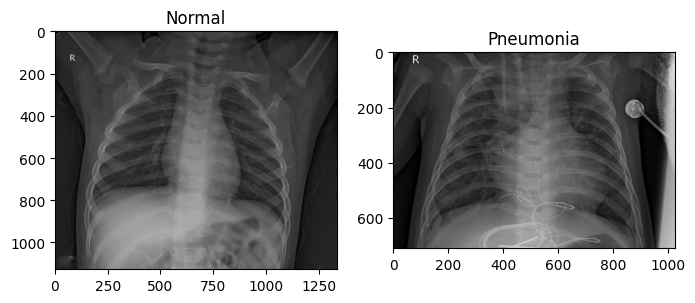

In [3]:

#Step-2:- Load AND Explore the data
#loading the data
train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
paths=[]
#print(len(os.listdir("/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL")))
for category in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(train_dir, category)
    paths.append(path)
    print(category, ":", len(os.listdir(path)))

#exploring the data
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

normal_img=mpimg.imread(os.path.join(paths[0],os.listdir(paths[0])[0]))
pneumonia_img=mpimg.imread(os.path.join(paths[1],os.listdir(paths[1])[0]))
print(normal_img,pneumonia_img)

fig,ax=plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(normal_img,cmap="gray")
ax[0].set_title("Normal")
ax[1].imshow(pneumonia_img,cmap="gray")
ax[1].set_title("Pneumonia")
plt.show()



In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#Step-3(Preprocessing the data)
#training data generator with augmentation
train_gen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

#validating data generator,with no augmentation, only rescaling
val_gen=ImageDataGenerator(
    rescale=1./255,
)

#testing data generator, with no augmentation, only rescaling
test_gen=ImageDataGenerator(
    rescale=1./255,
)

#Flows Images from directory
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

val_data=val_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

2025-12-29 13:35:07.776614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767015308.099293      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767015308.185364      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
from tensorflow.keras import models,layers
#Step-4:- Defining Model Architecture(input and output features)
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid"),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-29 13:35:34.281279: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
#Step-5:- Compile the model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [7]:
#Step-6:- Training the model
history=model.fit(train_data,epochs=10,validation_data=val_data)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.7511 - loss: 0.5793 - val_accuracy: 0.8750 - val_loss: 0.4371
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 966ms/step - accuracy: 0.8923 - loss: 0.2718 - val_accuracy: 0.7500 - val_loss: 0.5156
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 965ms/step - accuracy: 0.9060 - loss: 0.2391 - val_accuracy: 0.7500 - val_loss: 0.4531
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 156s 955ms/step - accuracy: 0.9059 - loss: 0.2252 - val_accuracy: 0.8125 - val_loss: 0.3965
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 156s 952ms/step - accuracy: 0.9272 - loss: 0.1826 - val_accuracy: 0.7500 - val_loss: 0.3742
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 201s 949ms/step - accuracy: 0.9237 - loss: 0.2026 - val_accuracy: 0.6875 - val_loss: 0.7361
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 950ms/step - accuracy: 0.9308 - loss: 0.1838 - val_accuracy: 0.6250 - val_loss: 0.9775
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 949ms/step - accuracy: 0.9361 - lo

In [8]:
#Step-7:- Evaluating the model on test data
test_loss,test_accuracy=model.evaluate(test_data)
print(test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 556ms/step - accuracy: 0.8901 - loss: 0.3481
0.8846153616905212


In [14]:
#Step-8:- Make predictions on new image 
from tensorflow.keras.preprocessing import image
import numpy as np

img_path="/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person101_bacteria_484.jpeg"
img=image.load_img(img_path,target_size=(150,150))
img_arr=image.img_to_array(img)/255.0
img_arr=np.expand_dims(img_arr,axis=0)

prediction=model.predict(img_arr)
diagnosis="PNEUMONIA" if prediction[0][0]>0.5 else "NORMAL"
print("Diagnosis:- ",diagnosis)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Diagnosis:-  PNEUMONIA


In [ ]:
#Step-1:- Import Necessary Libraries
import numpy as np

#Step-2:- Load and Explore the data 
train_dir=
val_dir=
test_dir=

#explore the data 

#finding total images
categories=["NORMAL","PNEUMONIA"]
#for training image
for category in categories:
    print(category,":",os.path.join(train_dir,category))
#for validation image
for category in categories:
    print(category,":",os.path.join(val_dir,category))
#for testing image
for category in categories:
    print(category,":",os.path.join(test_dir,category))

#displaying one image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path_1=os.path.join(train_dir,categories[0])
path_1=os.path.join(path_1,os.listdir(path_1)[0])

path_2=os.path.join(train_dir,categories[1])
path_2=os.path.join(path_2,os.listdir(path_2)[0])

img_1=mpimg.imread(path_1)
img_2=mpimg.imread(path_2)

fig,ax=plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(img_1)
ax[0].set_title("Normal")
ax[1].imshow(img_2)
ax[1].set_title("Pneumonia")

#Step-3:- Preprocessing the image 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#training image data generator
train_gen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
#validating image data Generator
val_gen=ImageDataGenerator(
    rescale=1./255,
)
#testing image data generator
test_gen=ImageDataGenerator(
    rescale=1./255,
)
#training images via training image generator
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)
#validating images from validating image generator
val_data=val_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)
#testing images from testing image generator
test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

#Step-4:- Defining model architecture
from tensorflow.keras import models,layers
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid"),
    
])

#Step-5:- Compile the model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

#Step-6:- Train the model
model.fit(train_data,epochs=10,validation_data=val_data)

#Step-7:- Evaluate the model
test_loss,test_accuracy=model.evaluate(test_data)
print("Accuracy:- ",test_accuracy)

#Step-8:- Prediction on new data
from tensorflow.keras.preprocessing import image
img_path=""
img=image.load_img(img_path,target_size=(150,150))
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)

predictions=model.predict(img_array)

diagnosis="Pneumonia" if predictions[0][0]>0.5 else "Normal"
print("Daignosis: ",diagnosis)

